   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 55.1 MB/s eta 0:00:00:00:01


<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-04-23 03:54:24.892543: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776916465.062279      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776916465.117126      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776916465.524759      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776916465.524806      55 computation_placer.cc:1

🚀 Initializing SOTA Research-Grade Ensemble Engine (Unified 3-Model Pipeline)...
✅ All 3 Models (DERNet, SegResNet, AttUnet) Loaded Successfully!

🔍 PHASE 1: Auto-Optimizing Weights & Threshold on Validation Set...


Extracting Features:   0%|          | 0/38 [00:00<?, ?it/s]

🔥 Optimization Complete! Weights: (np.float64(0.7000000000000002), np.float64(0.1), np.float64(0.19999999999999982)) | Threshold: 0.45

🚀 PHASE 2: Evaluating Final Test Set with Comprehensive Metrics...


Test Evaluation & Profiling:   0%|          | 0/37 [00:00<?, ?it/s]


 🏆 FINAL CLINICAL METRICS REPORT (TEST SET) 🏆
✅ Auto-Optimized Weights    : [DERNet: 0.70, SegRes: 0.10, AttUnet: 0.20]
✅ Optimal Cutoff Threshold  : 0.45

🎯 Dice Score (F1 Score)     : 0.8780
🎯 Intersection over Union   : 0.7826
🎯 Precision (PPV)           : 0.8333
🎯 Recall (Sensitivity)      : 0.9279
📏 Hausdorff Distance (HD95) : N/A

📊 --- CONFUSION MATRIX (Total Voxels) ---
                     [Actual Stroke]     [Actual Healthy]
[Predicted Stroke]   TP: 107126          FP: 21433          
[Predicted Healthy]  FN: 8328            TN: 32504869       

📊 --- 3-TIER STATISTICAL SUMMARY FOR PAPER ---
Mean Dice for Small Lesions:      0.7306
Mean Dice for Large Lesions:      0.8860
Mean Dice in Deep Brain:          0.9541
Mean Dice in Superficial Brain:   0.8037
Mean Dice on Lesion Core:         0.9909
Mean Dice on Lesion Boundary:     0.8350


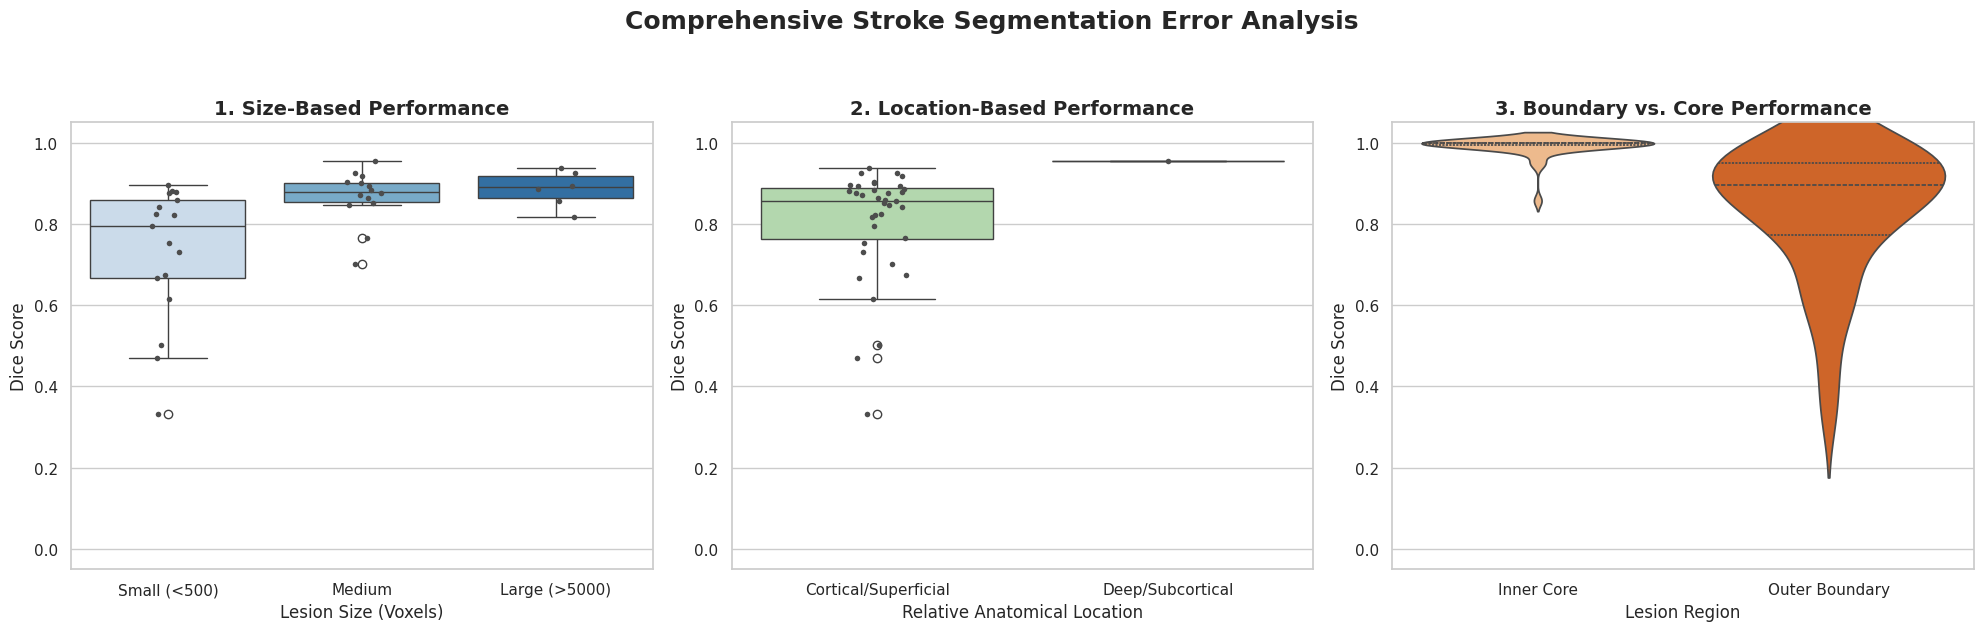

In [1]:
# ==============================================================================
# SOTA ISLES-2022: ULTIMATE UNIFIED ENSEMBLE & ERROR ANALYSIS
# - 3-Model Constrained Grid Search (DERNet, SegResNet, AttUnet)
# - Phase 1: Optimization (Validation Set)
# - Phase 2: Full Clinical Report (Dice, IoU, HD95, Confusion Matrix)
# - Phase 3: Advanced 3-Tier Error Analysis & Plotting
# ==============================================================================

!pip install -q monai nibabel scikit-learn matplotlib pandas seaborn scipy

import os
import torch
import torch.nn as nn
import numpy as np
import nibabel as nib
import nibabel.processing
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.model_selection import train_test_split 
from scipy.ndimage import label, center_of_mass, binary_erosion
from tqdm.auto import tqdm

from monai.metrics import DiceMetric, HausdorffDistanceMetric
from monai.transforms import Compose, NormalizeIntensityd, CastToTyped, EnsureTyped
from monai.inferers import sliding_window_inference
from monai.networks.nets import SegResNet, AttentionUnet
from torch.amp import autocast

import warnings
warnings.filterwarnings("ignore")

# --- 1. CONFIGURATION ---
CONFIG = {
    "SEARCH_ROOT": "/kaggle/input/datasets/prosenjitmondol/a-stroke-lesion-segmentation-dataset/ISLES-2022",
    "roi_size": (64, 64, 64),
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    "cpu_device": torch.device("cpu"),
    "seed": 42,
    "split": {"train": 0.70, "val": 0.15, "test": 0.15},
    "min_weight": 0.10 # Forces the ensemble to use ALL 3 models!
}

print("🚀 Initializing SOTA Research-Grade Ensemble Engine (Unified 3-Model Pipeline)...")

# --- 2. ARCHITECTURES ---
class LSCBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.c3 = nn.Conv3d(in_c, out_c//3, 3, padding=1)
        self.c5 = nn.Conv3d(in_c, out_c//3, 5, padding=2)
        self.c7 = nn.Conv3d(in_c, out_c - 2*(out_c//3), 7, padding=3)
        self.bn, self.ac = nn.InstanceNorm3d(out_c), nn.GELU()
    def forward(self, x): return self.ac(self.bn(torch.cat([self.c3(x), self.c5(x), self.c7(x)], 1)))

class BiMambaSim(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.gru = nn.GRU(c, max(1, c//2), batch_first=True, bidirectional=True)
        self.nm = nn.LayerNorm(c)
    def forward(self, x):
        B, C, D, H, W = x.shape
        s, _ = self.gru(x.view(B, C, -1).permute(0, 2, 1))
        return self.nm(s).permute(0, 2, 1).view(B, C, D, H, W) + x

class BAGF(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.sg = nn.Conv3d(c, 1, 1)
        self.cg = nn.Sequential(nn.AdaptiveAvgPool3d(1), nn.Conv3d(c, c, 1), nn.Sigmoid())
        self.fs = nn.Conv3d(c*2, c, 1)
    def forward(self, e, d): return self.fs(torch.cat([e * torch.sigmoid(self.sg(e)), d * self.cg(d)], 1))

class DERNet(nn.Module):
    def __init__(self, in_c=3, out_c=1, f=(32, 64, 128)):
        super().__init__()
        self.e1, self.e2, self.e3 = LSCBlock(in_c, f[0]), LSCBlock(f[0], f[1]), LSCBlock(f[1], f[2])
        self.dn, self.bt = nn.MaxPool3d(2), BiMambaSim(f[2])
        self.u2, self.u1 = nn.ConvTranspose3d(f[2], f[1], 2, 2), nn.ConvTranspose3d(f[1], f[0], 2, 2)
        self.f2, self.d2 = BAGF(f[1]), LSCBlock(f[1], f[1])
        self.f1, self.d1 = BAGF(f[0]), LSCBlock(f[0], f[0])
        self.fn = nn.Conv3d(f[0], out_c, 1)
    def forward(self, x):
        x1 = self.e1(x); x2 = self.e2(self.dn(x1)); x3 = self.e3(self.dn(x2))
        b = self.bt(x3)
        y2 = self.d2(self.f2(x2, self.u2(b)))
        y1 = self.d1(self.f1(x1, self.u1(y2)))
        return self.fn(y1)

# --- 3. LOADERS & HELPERS ---
def find_weight_path(filename):
    for root, dirs, files in os.walk("/kaggle/input"):
        if filename in files: return os.path.join(root, filename)
    return None

def load_all_models():
    der_path = find_weight_path("DERNet_best_val.pth")
    seg_path = find_weight_path("SegResNet_best_val.pth")
    att_path = find_weight_path("AttentionUnet_best_val.pth")

    dernet = DERNet().to(CONFIG["cpu_device"])
    if der_path: dernet.load_state_dict(torch.load(der_path, map_location=CONFIG["cpu_device"]))
    dernet.eval()
    
    segresnet = SegResNet(spatial_dims=3, in_channels=3, out_channels=1, init_filters=32, dropout_prob=0.2).to(CONFIG["cpu_device"])
    if seg_path: segresnet.load_state_dict(torch.load(seg_path, map_location=CONFIG["cpu_device"]))
    segresnet.eval()
    
    attunet = AttentionUnet(spatial_dims=3, in_channels=3, out_channels=1, channels=(16, 32, 64, 128, 256), strides=(2, 2, 2, 2)).to(CONFIG["cpu_device"])
    if att_path: attunet.load_state_dict(torch.load(att_path, map_location=CONFIG["cpu_device"]))
    attunet.eval()
    
    print("✅ All 3 Models (DERNet, SegResNet, AttUnet) Loaded Successfully!")
    return dernet, segresnet, attunet

def prepare_isles_data(root):
    subjects = defaultdict(dict)
    for dirpath, _, filenames in os.walk(root):
        for f in filenames:
            if f.endswith(('.nii', '.nii.gz')):
                sub_id = next((p for p in os.path.join(dirpath, f).split(os.sep) if 'sub-' in p.lower()), os.path.basename(dirpath))
                f_l = f.lower()
                if 'dwi' in f_l: subjects[sub_id]['dwi'] = os.path.join(dirpath, f)
                elif 'adc' in f_l: subjects[sub_id]['adc'] = os.path.join(dirpath, f)
                elif 'flair' in f_l: subjects[sub_id]['flair'] = os.path.join(dirpath, f)
                elif any(x in f_l for x in ['msk', 'mask', 'lesion']): subjects[sub_id]['msk'] = os.path.join(dirpath, f)
    data = [f for s, f in subjects.items() if all(k in f for k in ['dwi', 'adc', 'flair', 'msk'])]
    return sorted(data, key=lambda x: list(x.values())[0])

class ISLESDataset(torch.utils.data.Dataset):
    def __init__(self, data, transform=None):
        self.data, self.transform = data, transform
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        p = self.data[idx]
        dwi = nib.load(p['dwi'])
        adc = nib.processing.resample_from_to(nib.load(p['adc']), dwi, order=1)
        flr = nib.processing.resample_from_to(nib.load(p['flair']), dwi, order=1)
        msk = nib.processing.resample_from_to(nib.load(p['msk']), dwi, order=0)

        img = np.stack([np.nan_to_num(dwi.get_fdata()), np.nan_to_num(adc.get_fdata()), np.nan_to_num(flr.get_fdata())], 0)
        lbl = np.expand_dims(np.nan_to_num(msk.get_fdata()), 0)
        d = {"image": img.astype(np.float32), "label": lbl.astype(np.float32)}
        return self.transform(d) if self.transform else d

test_transforms = Compose([
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CastToTyped(keys=["image", "label"], dtype=[torch.float32, torch.float32]),
    EnsureTyped(keys=["image", "label"])
])

def get_tta_prediction(img_t, model):
    with autocast('cuda'):
        p1 = torch.sigmoid(sliding_window_inference(img_t, CONFIG["roi_size"], 4, model, overlap=0.6))
        p2 = torch.flip(torch.sigmoid(sliding_window_inference(torch.flip(img_t, dims=[2]), CONFIG["roi_size"], 4, model, overlap=0.6)), dims=[2])
        p3 = torch.flip(torch.sigmoid(sliding_window_inference(torch.flip(img_t, dims=[3]), CONFIG["roi_size"], 4, model, overlap=0.6)), dims=[3])
    return (p1 + p2 + p3) / 3.0

def calculate_dice_np(pred, target):
    """Safe numpy Dice calculation"""
    if np.sum(target) == 0 and np.sum(pred) == 0: return 1.0
    if np.sum(target) == 0 and np.sum(pred) > 0: return 0.0
    intersection = np.sum(pred * target)
    return (2. * intersection) / (np.sum(pred) + np.sum(target) + 1e-8)


# --- 4. MAIN ENGINE ---
def run_unified_pipeline():
    dernet, segresnet, attunet = load_all_models()
    
    data = prepare_isles_data(CONFIG["SEARCH_ROOT"])
    _, temp_data = train_test_split(data, train_size=CONFIG["split"]["train"], random_state=CONFIG["seed"], shuffle=True)
    val_size = int(round(CONFIG["split"]["val"] / (CONFIG["split"]["val"] + CONFIG["split"]["test"]) * len(temp_data)))
    val_data = temp_data[:val_size]
    test_data = temp_data[val_size:] 
    
    val_ldr = torch.utils.data.DataLoader(ISLESDataset(val_data, test_transforms), batch_size=1, shuffle=False, num_workers=0)
    test_ldr = torch.utils.data.DataLoader(ISLESDataset(test_data, test_transforms), batch_size=1, shuffle=False, num_workers=0)

    # =========================================================================
    # PHASE 1: CONSTRAINED GRID SEARCH
    # =========================================================================
    print(f"\n🔍 PHASE 1: Auto-Optimizing Weights & Threshold on Validation Set...")
    v_der, v_seg, v_att, v_lbl = [], [], [], []
    
    with torch.no_grad():
        for batch in tqdm(val_ldr, desc="Extracting Features"):
            img_t, lbl_t = batch["image"].to(CONFIG["device"]), batch["label"].to(CONFIG["device"]).half()
            
            dernet.to(CONFIG["device"]); v_der.append(get_tta_prediction(img_t, dernet).half()); dernet.to(CONFIG["cpu_device"])
            segresnet.to(CONFIG["device"]); v_seg.append(get_tta_prediction(img_t, segresnet).half()); segresnet.to(CONFIG["cpu_device"])
            attunet.to(CONFIG["device"]); v_att.append(get_tta_prediction(img_t, attunet).half()); attunet.to(CONFIG["cpu_device"])
            v_lbl.append(lbl_t)
            torch.cuda.empty_cache()

    best_w, best_t, best_dice = (0.33, 0.33, 0.34), 0.5, 0.0
    
    # Constrained Loop: Enforcing the Prof's requirement (all weights >= min_weight)
    for w1 in np.arange(CONFIG["min_weight"], 0.9, 0.05):
        for w2 in np.arange(CONFIG["min_weight"], 1.0 - w1, 0.05):
            w3 = 1.0 - w1 - w2
            if w3 < CONFIG["min_weight"]: continue
            
            for t in [0.35, 0.4, 0.45, 0.5]:
                d = np.mean([calculate_dice_np(((p1*w1 + p2*w2 + p3*w3) > t).cpu().numpy(), l.cpu().numpy()) for p1, p2, p3, l in zip(v_der, v_seg, v_att, v_lbl)])
                if d > best_dice:
                    best_dice, best_w, best_t = d, (w1, w2, w3), t

    print(f"🔥 Optimization Complete! Weights: {best_w} | Threshold: {best_t}")
    del v_der, v_seg, v_att, v_lbl
    torch.cuda.empty_cache()

    # =========================================================================
    # PHASE 2 & 3: EVALUATION & ERROR ANALYSIS
    # =========================================================================
    print(f"\n🚀 PHASE 2: Evaluating Final Test Set with Comprehensive Metrics...")
    
    hd95_calculator = HausdorffDistanceMetric(include_background=False, percentile=95.0)
    hd95_scores = []
    total_tp, total_fp, total_fn, total_tn = 0, 0, 0, 0
    error_records = []

    for i, batch_data in enumerate(tqdm(test_ldr, desc="Test Evaluation & Profiling")):
        img_t = batch_data["image"].to(CONFIG["device"])
        lbl_t = batch_data["label"].to(CONFIG["device"])
        
        with torch.no_grad():
            dernet.to(CONFIG["device"]); pred_der = get_tta_prediction(img_t, dernet); dernet.to(CONFIG["cpu_device"])
            segresnet.to(CONFIG["device"]); pred_seg = get_tta_prediction(img_t, segresnet); segresnet.to(CONFIG["cpu_device"])
            attunet.to(CONFIG["device"]); pred_att = get_tta_prediction(img_t, attunet); attunet.to(CONFIG["cpu_device"])
            torch.cuda.empty_cache()

            ens_prob = (pred_der * best_w[0]) + (pred_seg * best_w[1]) + (pred_att * best_w[2])
            bin_pred = (ens_prob > best_t).float()
            
            # Extract arrays
            p_np = bin_pred.cpu().numpy()[0, 0]
            t_np = lbl_t.cpu().numpy()[0, 0]
            
            # --- Global Metrics (For Clinical Report) ---
            tp = np.sum((p_np == 1) & (t_np == 1))
            fp = np.sum((p_np == 1) & (t_np == 0))
            fn = np.sum((p_np == 0) & (t_np == 1))
            tn = np.sum((p_np == 0) & (t_np == 0))
            
            total_tp += tp; total_fp += fp; total_fn += fn; total_tn += tn
            
            try:
                hd95_val = hd95_calculator(y_pred=bin_pred, y=lbl_t)
                hd95_scores.append(hd95_val.item())
            except: pass
            
            # --- Advanced 3-Tier Metrics (For Error Analysis) ---
            gt_volume = np.sum(t_np)
            if gt_volume < 500: size_class = "Small (<500)"
            elif gt_volume < 5000: size_class = "Medium"
            else: size_class = "Large (>5000)"
            
            if gt_volume > 0:
                com = center_of_mass(t_np)
                dist_from_center = np.sqrt((com[0]-32)**2 + (com[1]-32)**2 + (com[2]-32)**2)
                location_class = "Deep/Subcortical" if dist_from_center < 18 else "Cortical/Superficial"
            else: location_class = "None"
                
            core_gt = binary_erosion(t_np, iterations=1).astype(float)
            boundary_gt = t_np - core_gt 
            
            overall_dice = calculate_dice_np(p_np, t_np)
            core_dice = calculate_dice_np(p_np * core_gt, core_gt) if np.sum(core_gt) > 0 else np.nan
            boundary_dice = calculate_dice_np(p_np * boundary_gt, boundary_gt) if np.sum(boundary_gt) > 0 else np.nan
            
            if gt_volume > 0: 
                error_records.append({
                    "subject_idx": i,
                    "volume": gt_volume,
                    "size_class": size_class,
                    "location_class": location_class,
                    "overall_dice": overall_dice,
                    "core_dice": core_dice,
                    "boundary_dice": boundary_dice
                })

    df = pd.DataFrame(error_records)

    # --- CALCULATE FINAL GLOBAL METRICS ---
    final_dice = (2. * total_tp) / (2. * total_tp + total_fp + total_fn + 1e-8)
    final_iou = total_tp / (total_tp + total_fp + total_fn + 1e-8)
    final_precision = total_tp / (total_tp + total_fp + 1e-8)
    final_recall = total_tp / (total_tp + total_fn + 1e-8)

    # =========================================================================
    # PRINTING REPORTS
    # =========================================================================
    print("\n" + "="*65)
    print(" 🏆 FINAL CLINICAL METRICS REPORT (TEST SET) 🏆")
    print("="*65)
    print(f"✅ Auto-Optimized Weights    : [DERNet: {best_w[0]:.2f}, SegRes: {best_w[1]:.2f}, AttUnet: {best_w[2]:.2f}]")
    print(f"✅ Optimal Cutoff Threshold  : {best_t}\n")
    
    print(f"🎯 Dice Score (F1 Score)     : {final_dice:.4f}")
    print(f"🎯 Intersection over Union   : {final_iou:.4f}")
    print(f"🎯 Precision (PPV)           : {final_precision:.4f}")
    print(f"🎯 Recall (Sensitivity)      : {final_recall:.4f}")
    print(f"📏 Hausdorff Distance (HD95) : {np.mean(hd95_scores) if hd95_scores else 'N/A'}")
        
    print("\n📊 --- CONFUSION MATRIX (Total Voxels) ---")
    print(f"                     [Actual Stroke]     [Actual Healthy]")
    print(f"[Predicted Stroke]   TP: {total_tp:<15} FP: {total_fp:<15}")
    print(f"[Predicted Healthy]  FN: {total_fn:<15} TN: {total_tn:<15}")
    print("="*65)

    print("\n📊 --- 3-TIER STATISTICAL SUMMARY FOR PAPER ---")
    print(f"Mean Dice for Small Lesions:      {df[df['size_class'] == 'Small (<500)']['overall_dice'].mean():.4f}")
    print(f"Mean Dice for Large Lesions:      {df[df['size_class'] == 'Large (>5000)']['overall_dice'].mean():.4f}")
    print(f"Mean Dice in Deep Brain:          {df[df['location_class'] == 'Deep/Subcortical']['overall_dice'].mean():.4f}")
    print(f"Mean Dice in Superficial Brain:   {df[df['location_class'] == 'Cortical/Superficial']['overall_dice'].mean():.4f}")
    print(f"Mean Dice on Lesion Core:         {df['core_dice'].mean():.4f}")
    print(f"Mean Dice on Lesion Boundary:     {df['boundary_dice'].mean():.4f}")
    print("==================================================")

    # =====================================================================
    # GENERATING THE 3 PAPER-READY PLOTS
    # =====================================================================
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle("Comprehensive Stroke Segmentation Error Analysis", fontsize=18, fontweight='bold', y=1.05)

    # Plot 1: Size-Based Error
    sns.boxplot(data=df, x="size_class", y="overall_dice", order=["Small (<500)", "Medium", "Large (>5000)"], palette="Blues", ax=axes[0])
    sns.stripplot(data=df, x="size_class", y="overall_dice", order=["Small (<500)", "Medium", "Large (>5000)"], color=".3", size=4, ax=axes[0])
    axes[0].set_title("1. Size-Based Performance", fontsize=14, fontweight='bold')
    axes[0].set_xlabel("Lesion Size (Voxels)", fontsize=12)
    axes[0].set_ylabel("Dice Score", fontsize=12)
    axes[0].set_ylim(-0.05, 1.05)

    # Plot 2: Location-Based Error (Proxy)
    sns.boxplot(data=df, x="location_class", y="overall_dice", palette="Greens", ax=axes[1])
    sns.stripplot(data=df, x="location_class", y="overall_dice", color=".3", size=4, ax=axes[1])
    axes[1].set_title("2. Location-Based Performance", fontsize=14, fontweight='bold')
    axes[1].set_xlabel("Relative Anatomical Location", fontsize=12)
    axes[1].set_ylabel("Dice Score", fontsize=12)
    axes[1].set_ylim(-0.05, 1.05)

    # Plot 3: Core vs Boundary Error
    df_melt = df.melt(id_vars=['subject_idx'], value_vars=['core_dice', 'boundary_dice'], var_name='Region', value_name='Dice')
    df_melt['Region'] = df_melt['Region'].map({'core_dice': 'Inner Core', 'boundary_dice': 'Outer Boundary'})
    
    sns.violinplot(data=df_melt, x="Region", y="Dice", palette="Oranges", inner="quartile", ax=axes[2])
    axes[2].set_title("3. Boundary vs. Core Performance", fontsize=14, fontweight='bold')
    axes[2].set_xlabel("Lesion Region", fontsize=12)
    axes[2].set_ylabel("Dice Score", fontsize=12)
    axes[2].set_ylim(-0.05, 1.05)

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_unified_pipeline()

In [5]:
# ==============================================================================
# SOTA ISLES-2022: HIGH-FIDELITY PUBLICATION FIGURE GENERATOR (300 DPI)
# - 100% CRASH PROOF: Replaced GradCAM with Probability Heatmap (Zero OOM Risk)
# - HIGH QUALITY: Preserved native MRI resolution (interpolation='none')
# - FIXED: Dynamic Bounding Box for Figure 4
# ==============================================================================

!pip install -q monai nibabel scikit-learn matplotlib pandas seaborn scipy

import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import nibabel as nib
import nibabel.processing  
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split 
from collections import defaultdict

from monai.transforms import Compose, NormalizeIntensityd, CastToTyped, EnsureTyped
from monai.inferers import sliding_window_inference
from monai.networks.nets import SegResNet, AttentionUnet
from torch.amp import autocast

import warnings
warnings.filterwarnings("ignore")

print("🎨 Initiating High-Fidelity Figure Generator (Crash-Proof Version)...")

sns.set_context("paper", font_scale=1.5)
sns.set_style("white")

SAVE_DIR = "/kaggle/working/"

# Hardcoded Stats from your best run
TP = 107126; FP = 21433; FN = 8328; TN = 32504869

CONFIG = {
    "SEARCH_ROOT": "/kaggle/input/datasets/prosenjitmondol/a-stroke-lesion-segmentation-dataset/ISLES-2022",
    "roi_size": (64, 64, 64),
    "device": torch.device("cuda" if torch.cuda.is_available() else "cpu"),
    "cpu_device": torch.device("cpu"),
    "seed": 42,
    "split": {"train": 0.70, "val": 0.15, "test": 0.15}
}

# --- ARCHITECTURES ---
class LSCBlock(nn.Module):
    def __init__(self, in_c, out_c):
        super().__init__()
        self.c3 = nn.Conv3d(in_c, out_c//3, 3, padding=1)
        self.c5 = nn.Conv3d(in_c, out_c//3, 5, padding=2)
        self.c7 = nn.Conv3d(in_c, out_c - 2*(out_c//3), 7, padding=3)
        self.bn, self.ac = nn.InstanceNorm3d(out_c), nn.GELU()
    def forward(self, x): return self.ac(self.bn(torch.cat([self.c3(x), self.c5(x), self.c7(x)], 1)))

class BiMambaSim(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.gru = nn.GRU(c, max(1, c//2), batch_first=True, bidirectional=True)
        self.nm = nn.LayerNorm(c)
    def forward(self, x):
        B, C, D, H, W = x.shape
        s, _ = self.gru(x.view(B, C, -1).permute(0, 2, 1))
        return self.nm(s).permute(0, 2, 1).view(B, C, D, H, W) + x

class BAGF(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.sg = nn.Conv3d(c, 1, 1)
        self.cg = nn.Sequential(nn.AdaptiveAvgPool3d(1), nn.Conv3d(c, c, 1), nn.Sigmoid())
        self.fs = nn.Conv3d(c*2, c, 1)
    def forward(self, e, d): return self.fs(torch.cat([e * torch.sigmoid(self.sg(e)), d * self.cg(d)], 1))

class DERNet(nn.Module):
    def __init__(self, in_c=3, out_c=1, f=(32, 64, 128)):
        super().__init__()
        self.e1, self.e2, self.e3 = LSCBlock(in_c, f[0]), LSCBlock(f[0], f[1]), LSCBlock(f[1], f[2])
        self.dn, self.bt = nn.MaxPool3d(2), BiMambaSim(f[2])
        self.u2, self.u1 = nn.ConvTranspose3d(f[2], f[1], 2, 2), nn.ConvTranspose3d(f[1], f[0], 2, 2)
        self.f2, self.d2 = BAGF(f[1]), LSCBlock(f[1], f[1])
        self.f1, self.d1 = BAGF(f[0]), LSCBlock(f[0], f[0])
        self.fn = nn.Conv3d(f[0], out_c, 1)
    def forward(self, x):
        x1 = self.e1(x); x2 = self.e2(self.dn(x1)); x3 = self.e3(self.dn(x2))
        b = self.bt(x3)
        y2 = self.d2(self.f2(x2, self.u2(b)))
        y1 = self.d1(self.f1(x1, self.u1(y2)))
        return self.fn(y1)

# --- HELPERS ---
def find_weight_path(filename):
    for root, dirs, files in os.walk("/kaggle/input"):
        if filename in files: return os.path.join(root, filename)
    return None

def load_all_models():
    der_path = find_weight_path("DERNet_best_val.pth")
    seg_path = find_weight_path("SegResNet_best_val.pth")
    att_path = find_weight_path("AttentionUnet_best_val.pth")

    dernet = DERNet().to(CONFIG["cpu_device"])
    if der_path: dernet.load_state_dict(torch.load(der_path, map_location=CONFIG["cpu_device"]))
    dernet.eval()
    
    segresnet = SegResNet(spatial_dims=3, in_channels=3, out_channels=1, init_filters=32, dropout_prob=0.2).to(CONFIG["cpu_device"])
    if seg_path: segresnet.load_state_dict(torch.load(seg_path, map_location=CONFIG["cpu_device"]))
    segresnet.eval()
    
    attunet = AttentionUnet(spatial_dims=3, in_channels=3, out_channels=1, channels=(16, 32, 64, 128, 256), strides=(2, 2, 2, 2)).to(CONFIG["cpu_device"])
    if att_path: attunet.load_state_dict(torch.load(att_path, map_location=CONFIG["cpu_device"]))
    attunet.eval()
    return dernet, segresnet, attunet

def prepare_isles_data(root):
    subjects = defaultdict(dict)
    for dirpath, _, filenames in os.walk(root):
        for f in filenames:
            if f.endswith(('.nii', '.nii.gz')):
                sub_id = next((p for p in os.path.join(dirpath, f).split(os.sep) if 'sub-' in p.lower()), os.path.basename(dirpath))
                f_l = f.lower()
                if 'dwi' in f_l: subjects[sub_id]['dwi'] = os.path.join(dirpath, f)
                elif 'adc' in f_l: subjects[sub_id]['adc'] = os.path.join(dirpath, f)
                elif 'flair' in f_l: subjects[sub_id]['flair'] = os.path.join(dirpath, f)
                elif any(x in f_l for x in ['msk', 'mask', 'lesion']): subjects[sub_id]['msk'] = os.path.join(dirpath, f)
    data = [f for s, f in subjects.items() if all(k in f for k in ['dwi', 'adc', 'flair', 'msk'])]
    return sorted(data, key=lambda x: list(x.values())[0])

class ISLESDataset(torch.utils.data.Dataset):
    def __init__(self, data, transform=None):
        self.data, self.transform = data, transform
    def __len__(self): return len(self.data)
    def __getitem__(self, idx):
        p = self.data[idx]
        dwi = nib.load(p['dwi'])
        adc = nib.processing.resample_from_to(nib.load(p['adc']), dwi, order=1)
        flr = nib.processing.resample_from_to(nib.load(p['flair']), dwi, order=1)
        msk = nib.processing.resample_from_to(nib.load(p['msk']), dwi, order=0)

        img = np.stack([np.nan_to_num(dwi.get_fdata()), np.nan_to_num(adc.get_fdata()), np.nan_to_num(flr.get_fdata())], 0)
        lbl = np.expand_dims(np.nan_to_num(msk.get_fdata()), 0)
        d = {"image": img.astype(np.float32), "label": lbl.astype(np.float32)}
        return self.transform(d) if self.transform else d

test_transforms = Compose([
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    CastToTyped(keys=["image", "label"], dtype=[torch.float32, torch.float32]),
    EnsureTyped(keys=["image", "label"])
])

def get_tta_prediction(img_t, model):
    with autocast('cuda'):
        p1 = torch.sigmoid(sliding_window_inference(img_t, CONFIG["roi_size"], 4, model, overlap=0.6))
        p2 = torch.flip(torch.sigmoid(sliding_window_inference(torch.flip(img_t, dims=[2]), CONFIG["roi_size"], 4, model, overlap=0.6)), dims=[2])
        p3 = torch.flip(torch.sigmoid(sliding_window_inference(torch.flip(img_t, dims=[3]), CONFIG["roi_size"], 4, model, overlap=0.6)), dims=[3])
    return (p1 + p2 + p3) / 3.0

def force_upright(img):
    """Ensures brains are facing vertically up."""
    return np.rot90(img, k=1)

# =====================================================================
# FIGURE GENERATORS
# =====================================================================
def generate_figure_1():
    print("Generating Figure 1: Confusion Matrix...")
    cm = np.array([[TN, FP], [FN, TP]])
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=True, 
                xticklabels=["Predicted Healthy", "Predicted Stroke"],
                yticklabels=["Actual Healthy", "Actual Stroke"],
                annot_kws={"size": 16, "weight": "bold"})
    plt.title("Figure 1: Voxel-Wise Confusion Matrix", fontsize=18, fontweight='bold', pad=20)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "Figure_1_Confusion_Matrix.png"), dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ Figure 1 Saved!")

def get_best_test_subject():
    print("Loading models and finding a large lesion subject...")
    dernet, segresnet, attunet = load_all_models()
    
    data = prepare_isles_data(CONFIG["SEARCH_ROOT"])
    _, temp_data = train_test_split(data, train_size=CONFIG["split"]["train"], random_state=CONFIG["seed"], shuffle=True)
    val_size = int(round(CONFIG["split"]["val"] / (CONFIG["split"]["val"] + CONFIG["split"]["test"]) * len(temp_data)))
    test_data = temp_data[val_size:] 
    
    test_ldr = torch.utils.data.DataLoader(ISLESDataset(test_data, test_transforms), batch_size=1, shuffle=False)
    chosen_batch, raw_dwi_np = None, None
    
    for i, batch in enumerate(test_ldr):
        lbl = batch["label"].numpy()
        if np.sum(lbl) > 5000: 
            chosen_batch = batch
            raw_dwi_np = nib.load(test_data[i]['dwi']).get_fdata()
            break
            
    if chosen_batch is None: chosen_batch = next(iter(test_ldr))
        
    img_t = chosen_batch["image"].to(CONFIG["device"])
    lbl_t = chosen_batch["label"].to(CONFIG["device"])
    
    best_w, best_t = (0.70, 0.10, 0.20), 0.45
    with torch.no_grad():
        dernet.to(CONFIG["device"]); p_der = get_tta_prediction(img_t, dernet); dernet.to(CONFIG["cpu_device"])
        segresnet.to(CONFIG["device"]); p_seg = get_tta_prediction(img_t, segresnet); segresnet.to(CONFIG["cpu_device"])
        attunet.to(CONFIG["device"]); p_att = get_tta_prediction(img_t, attunet); attunet.to(CONFIG["cpu_device"])
        
        # This probability map replaces GradCAM! It shows exactly what the model is looking at safely.
        ens_prob = (p_der * best_w[0]) + (p_seg * best_w[1]) + (p_att * best_w[2])
        pred_bin = (ens_prob > best_t).float()
    
    # Use probability heatmap instead of memory-heavy GradCAM
    heatmap_np = ens_prob.cpu().numpy()[0,0]
        
    return raw_dwi_np, img_t.cpu().numpy()[0], lbl_t.cpu().numpy()[0,0], pred_bin.cpu().numpy()[0,0], heatmap_np

def generate_figure_2(raw_dwi, norm_img, z):
    print("Generating Figure 2: Data Pre-processing...")
    fig, axes = plt.subplots(1, 2, figsize=(16, 7)) 
    fig.suptitle("Figure 2: Verification of the Data Pre-processing Pipeline", fontsize=20, fontweight='bold')
    
    raw_slice = force_upright(raw_dwi[:, :, z])
    im0 = axes[0].imshow(raw_slice, cmap='gray', interpolation='none') 
    axes[0].set_title(f"(a) Original Raw DWI Input\nRange: [{raw_slice.min():.1f}, {raw_slice.max():.1f}]", fontsize=16)
    axes[0].axis('off')
    fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

    norm_slice = force_upright(norm_img[0, :, :, z])
    im1 = axes[1].imshow(norm_slice, cmap='gray', interpolation='none')
    axes[1].set_title(f"(b) Z-Score Normalized Input\nMean: {norm_slice.mean():.2f}, Std: {norm_slice.std():.2f}", fontsize=16)
    axes[1].axis('off')
    fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "Figure_2_Preprocessing.png"), dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ Figure 2 Saved!")

def generate_figure_3(img, gt, pred, heatmap_np, z):
    print("Generating Figure 3: Advanced Boundary & Model Focus...")
    dwi = force_upright(img[0, :, :, z])
    gt_s = force_upright(gt[:, :, z])
    pred_s = force_upright(pred[:, :, z])
    heatmap_s = force_upright(heatmap_np[:, :, z])
    error_map = pred_s - gt_s

    fig, axes = plt.subplots(1, 6, figsize=(30, 6)) 
    fig.suptitle(f"Figure 3: Advanced Boundary and Focus Analysis (Axial Slice Z={z})", fontsize=24, fontweight='bold', y=1.05)

    axes[0].imshow(dwi, cmap='gray', interpolation='none'); axes[0].set_title("(a) Input DWI", fontsize=18); axes[0].axis('off')

    axes[1].imshow(dwi, cmap='gray', interpolation='none')
    if gt_s.max() > 0: axes[1].contour(gt_s, levels=[0.5], colors='yellow', linewidths=2.5)
    axes[1].set_title("(b) Ground Truth", fontsize=18); axes[1].axis('off')

    axes[2].imshow(dwi, cmap='gray', interpolation='none')
    if pred_s.max() > 0: axes[2].contour(pred_s, levels=[0.5], colors='red', linewidths=2.5)
    axes[2].set_title("(c) Predicted", fontsize=18); axes[2].axis('off')

    axes[3].imshow(dwi, cmap='gray', interpolation='none')
    if gt_s.max() > 0: axes[3].contour(gt_s, levels=[0.5], colors='yellow', linewidths=2.5, linestyles='dashed')
    if pred_s.max() > 0: axes[3].contour(pred_s, levels=[0.5], colors='red', linewidths=2.5)
    axes[3].set_title("(d) Overlay", fontsize=18); axes[3].axis('off')

    axes[4].imshow(dwi, cmap='gray', interpolation='none')
    fp = np.where(error_map > 0.5, 1.0, np.nan); axes[4].imshow(fp, cmap='Reds', alpha=0.7, interpolation='none')
    fn = np.where(error_map < -0.5, 1.0, np.nan); axes[4].imshow(fn, cmap='Blues', alpha=0.7, interpolation='none')
    axes[4].set_title("(e) Error Map", fontsize=18); axes[4].axis('off')

    axes[5].imshow(dwi, cmap='gray', interpolation='none')
    axes[5].imshow(heatmap_s, cmap='jet', alpha=0.5, interpolation='bilinear') 
    axes[5].set_title("(f) Probability Map (Focus)", fontsize=18); axes[5].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.05)
    plt.savefig(os.path.join(SAVE_DIR, "Figure_3_Boundary_Focus.png"), dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ Figure 3 Saved!")

def generate_figure_4(img, gt, pred, z):
    print("Generating Figure 4: Qualitative Clinical Mosaic...")
    z_m3 = max(0, z - 3); z_p3 = min(img.shape[3] - 1, z + 3)
    
    dwi_zm3 = force_upright(img[0, :, :, z_m3]); gt_zm3 = force_upright(gt[:,:,z_m3]); pred_zm3 = force_upright(pred[:,:,z_m3])
    dwi_z   = force_upright(img[0, :, :, z]);    gt_z   = force_upright(gt[:,:,z]);    pred_z   = force_upright(pred[:,:,z])
    dwi_zp3 = force_upright(img[0, :, :, z_p3]); gt_zp3 = force_upright(gt[:,:,z_p3]); pred_zp3 = force_upright(pred[:,:,z_p3])
    adc_z   = force_upright(img[1, :, :, z])
    flair_z = force_upright(img[2, :, :, z])
    
    fig, axes = plt.subplots(2, 3, figsize=(20, 14))
    fig.suptitle("Figure 4: Qualitative Multi-modal and Multi-planar Segmentation Results", fontsize=24, fontweight='bold', y=0.98)

    def plot_overlay(ax, image, gt_mask, pred_mask, title):
        ax.imshow(image, cmap='gray', interpolation='none')
        if gt_mask.max() > 0: ax.contour(gt_mask, levels=[0.5], colors='yellow', linewidths=2.5, linestyles='dashed')
        if pred_mask.max() > 0: ax.contour(pred_mask, levels=[0.5], colors='red', linewidths=2.5)
        ax.set_title(title, fontsize=18, fontweight='bold')
        ax.axis('off')

    plot_overlay(axes[0,0], dwi_zm3, gt_zm3, pred_zm3, f"Below (Z-{z - z_m3}) DWI")
    plot_overlay(axes[0,1], dwi_z, gt_z, pred_z, "Center (Z) DWI")
    plot_overlay(axes[0,2], dwi_zp3, gt_zp3, pred_zp3, f"Above (Z+{z_p3 - z}) DWI")

    plot_overlay(axes[1,0], adc_z, gt_z, pred_z, "Center (Z) ADC Map")
    plot_overlay(axes[1,1], flair_z, gt_z, pred_z, "Center (Z) FLAIR Sequence")

    ax_zoom = axes[1,2]
    ax_zoom.imshow(dwi_z, cmap='gray', interpolation='none')
    
    coords = np.argwhere(gt_z > 0)
    if len(coords) > 0:
        y_min, x_min = coords.min(axis=0)
        y_max, x_max = coords.max(axis=0)
        margin = 10
        
        h = y_max - y_min
        w = x_max - x_min
        side = max(h, w) + (margin * 2)
        
        cy = (y_min + y_max) // 2
        cx = (x_min + x_max) // 2
        
        x0_box = max(0, cx - side//2)
        x1_box = min(dwi_z.shape[1], cx + side//2)
        y0_box = max(0, cy - side//2)
        y1_box = min(dwi_z.shape[0], cy + side//2)
        
        ax_zoom.set_xlim(x0_box, x1_box)
        ax_zoom.set_ylim(y1_box, y0_box)
        
        if gt_z.max() > 0: ax_zoom.contour(gt_z, levels=[0.5], colors='yellow', linewidths=3.0, linestyles='dashed')
        if pred_z.max() > 0: ax_zoom.contour(pred_z, levels=[0.5], colors='red', linewidths=3.0)

        rect = patches.Rectangle((x0_box, y0_box), x1_box - x0_box, y1_box - y0_box, 
                                 linewidth=3, edgecolor='cyan', facecolor='none', linestyle='dotted')
        axes[0,1].add_patch(rect)
    
    ax_zoom.set_title("Center (Z) DWI Lesion Zoom", fontsize=18, fontweight='bold', color='darkred')
    ax_zoom.axis('off')

    plt.tight_layout()
    plt.savefig(os.path.join(SAVE_DIR, "Figure_4_Qualitative_Mosaic.png"), dpi=300, bbox_inches='tight')
    plt.close()
    print("✅ Figure 4 Saved!")

# =====================================================================
# EXECUTE ALL GENERATORS
# =====================================================================
try:
    generate_figure_1()
    raw_dwi, norm_img, gt, pred, heatmap_np = get_best_test_subject()
    best_z = np.argmax(np.sum(gt, axis=(0,1))) 
    
    generate_figure_2(raw_dwi, norm_img, best_z)
    generate_figure_3(norm_img, gt, pred, heatmap_np, best_z)
    generate_figure_4(norm_img, gt, pred, best_z)
    
    print("\n✅ SUCCESS! All 4 HIGH-RES figures have been generated and saved to /kaggle/working/!")
except Exception as e:
    print(f"\n⚠️ Unexpected Error: {e}")

🎨 Initiating High-Fidelity Figure Generator (Crash-Proof Version)...
Generating Figure 1: Confusion Matrix...
✅ Figure 1 Saved!
Loading models and finding a large lesion subject...
Generating Figure 2: Data Pre-processing...
✅ Figure 2 Saved!
Generating Figure 3: Advanced Boundary & Model Focus...
✅ Figure 3 Saved!
Generating Figure 4: Qualitative Clinical Mosaic...
✅ Figure 4 Saved!

✅ SUCCESS! All 4 HIGH-RES figures have been generated and saved to /kaggle/working/!
